# LIF interoperability experiment: paper reproduction with NeuroHLS

This notebook reproduces the 1,000-step single-neuron experiment from Pedersen et al. (2024), using the official NIR graph and stimulus. It compares the generated **time-driven** NeuroHLS CSim trace with the official simulator/hardware traces.

Both the NIR reference and NeuroHLS use subtractive reset (reset by subtract), evaluating the exact same 1,000-step dataset used by the other reference libraries.

In [1]:
from pathlib import Path
import os, sys
import numpy as np

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'neuro_hls').is_dir() else cwd.parent
sys.path.insert(0, str(repo_root / 'validation'))
import common as vc
import matplotlib.pyplot as plt

RUN_CSIM = vc.env_flag('NEUROHLS_RUN_CSIM', True)
FORCE = vc.env_flag('NEUROHLS_FORCE', False)
TIMEOUT_MINUTES = vc.env_int('NEUROHLS_TIMEOUT_MINUTES', 420)
USE_FLOAT = os.environ.get('NEUROHLS_ARITHMETIC', 'float').casefold() == 'float'
vc.ensure_directories()
print({'run_csim': RUN_CSIM, 'force': FORCE, 'arithmetic': 'float' if USE_FLOAT else 'fixed-point'})
print('Reset mechanism: subtract (reset by subtraction)')

{'run_csim': True, 'force': False, 'arithmetic': 'float'}
Reset mechanism: subtract (reset by subtraction)


## Generate the NeuroHLS project and run through CSim

A validation-only output probe exposes the LIF membrane state after every generated top-level call.

In [2]:
project = vc.generate_lif_project(use_float=USE_FLOAT, reset_by_subtraction=True, force=FORCE)
run_dir = vc.run_csim(project, timeout_minutes=TIMEOUT_MINUTES, execute=RUN_CSIM, force=FORCE)
trace = vc.parse_lif_trace(run_dir)
trace.to_csv(vc.RESULTS_ROOT / 'lif_neurohls_trace.csv', index=False)
vc.save_json(vc.RESULTS_ROOT / 'lif_csim_summary.json', vc.run_summary(run_dir))
vc.save_json(
    vc.RESULTS_ROOT / 'lif_provenance.json',
    vc.provenance(
        {'nir': vc.NIR_EXAMPLES / 'lif_norse.nir', 'dataset': vc.prepare_lif_dataset()},
        backend='time-driven', parallelism_p=0.0,
        arithmetic='float' if USE_FLOAT else 'fixed-point',
        steps=1000, dt_seconds=1e-4, run_dir=str(run_dir),
        reset_note='NeuroHLS LIF uses subtractive reset matching the NIR reference',
    ),
)
print(f'CSim run: {run_dir}')
print(f"NeuroHLS output spikes: {np.flatnonzero(trace['spike'].to_numpy() > 0).tolist()}")

Total samples used: 1 of 1
Batch size: 1
Total batches: 1
Testbench was created.
CSim run: /home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/runs/lif_float_subtract_probe/20260819T030713Z-7aa08276d470
NeuroHLS output spikes: [460, 510, 710, 760]


## Numerical comparison

Each voltage trace is normalised by its own maximum, matching the official plotting notebook. Spike lag is measured against the exact reference trace.

In [3]:
references = vc.load_lif_references()
comparison = vc.lif_comparison_table(references, trace)
comparison.to_csv(vc.RESULTS_ROOT / 'lif_comparison.csv', index=False)
print(comparison.to_string(index=False))

       library  spike_count     spike_steps  mean_abs_spike_lag_steps  normalised_voltage_rmse  normalised_voltage_cosine
         Exact            4 460 510 710 760                       0.0                 0.000000                   1.000000
Lava CPU fixed            4 461 511 711 761                       1.0                 0.080565                   0.972997
Lava CPU float            4 461 511 711 761                       1.0                 0.080252                   0.973257
  Lava Loihi 2            4 461 511 711 761                       1.0                 0.080559                   0.973002
         Nengo            4 460 510 710 760                       0.0                 0.010178                   0.999619
         Norse            4 460 510 710 760                       0.0                 0.010005                   0.999637
      Rockpool            4 450 500 710 760                       5.0                 0.130963                   0.931892
        Sinabs          

/home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/results/lif_comparison.png


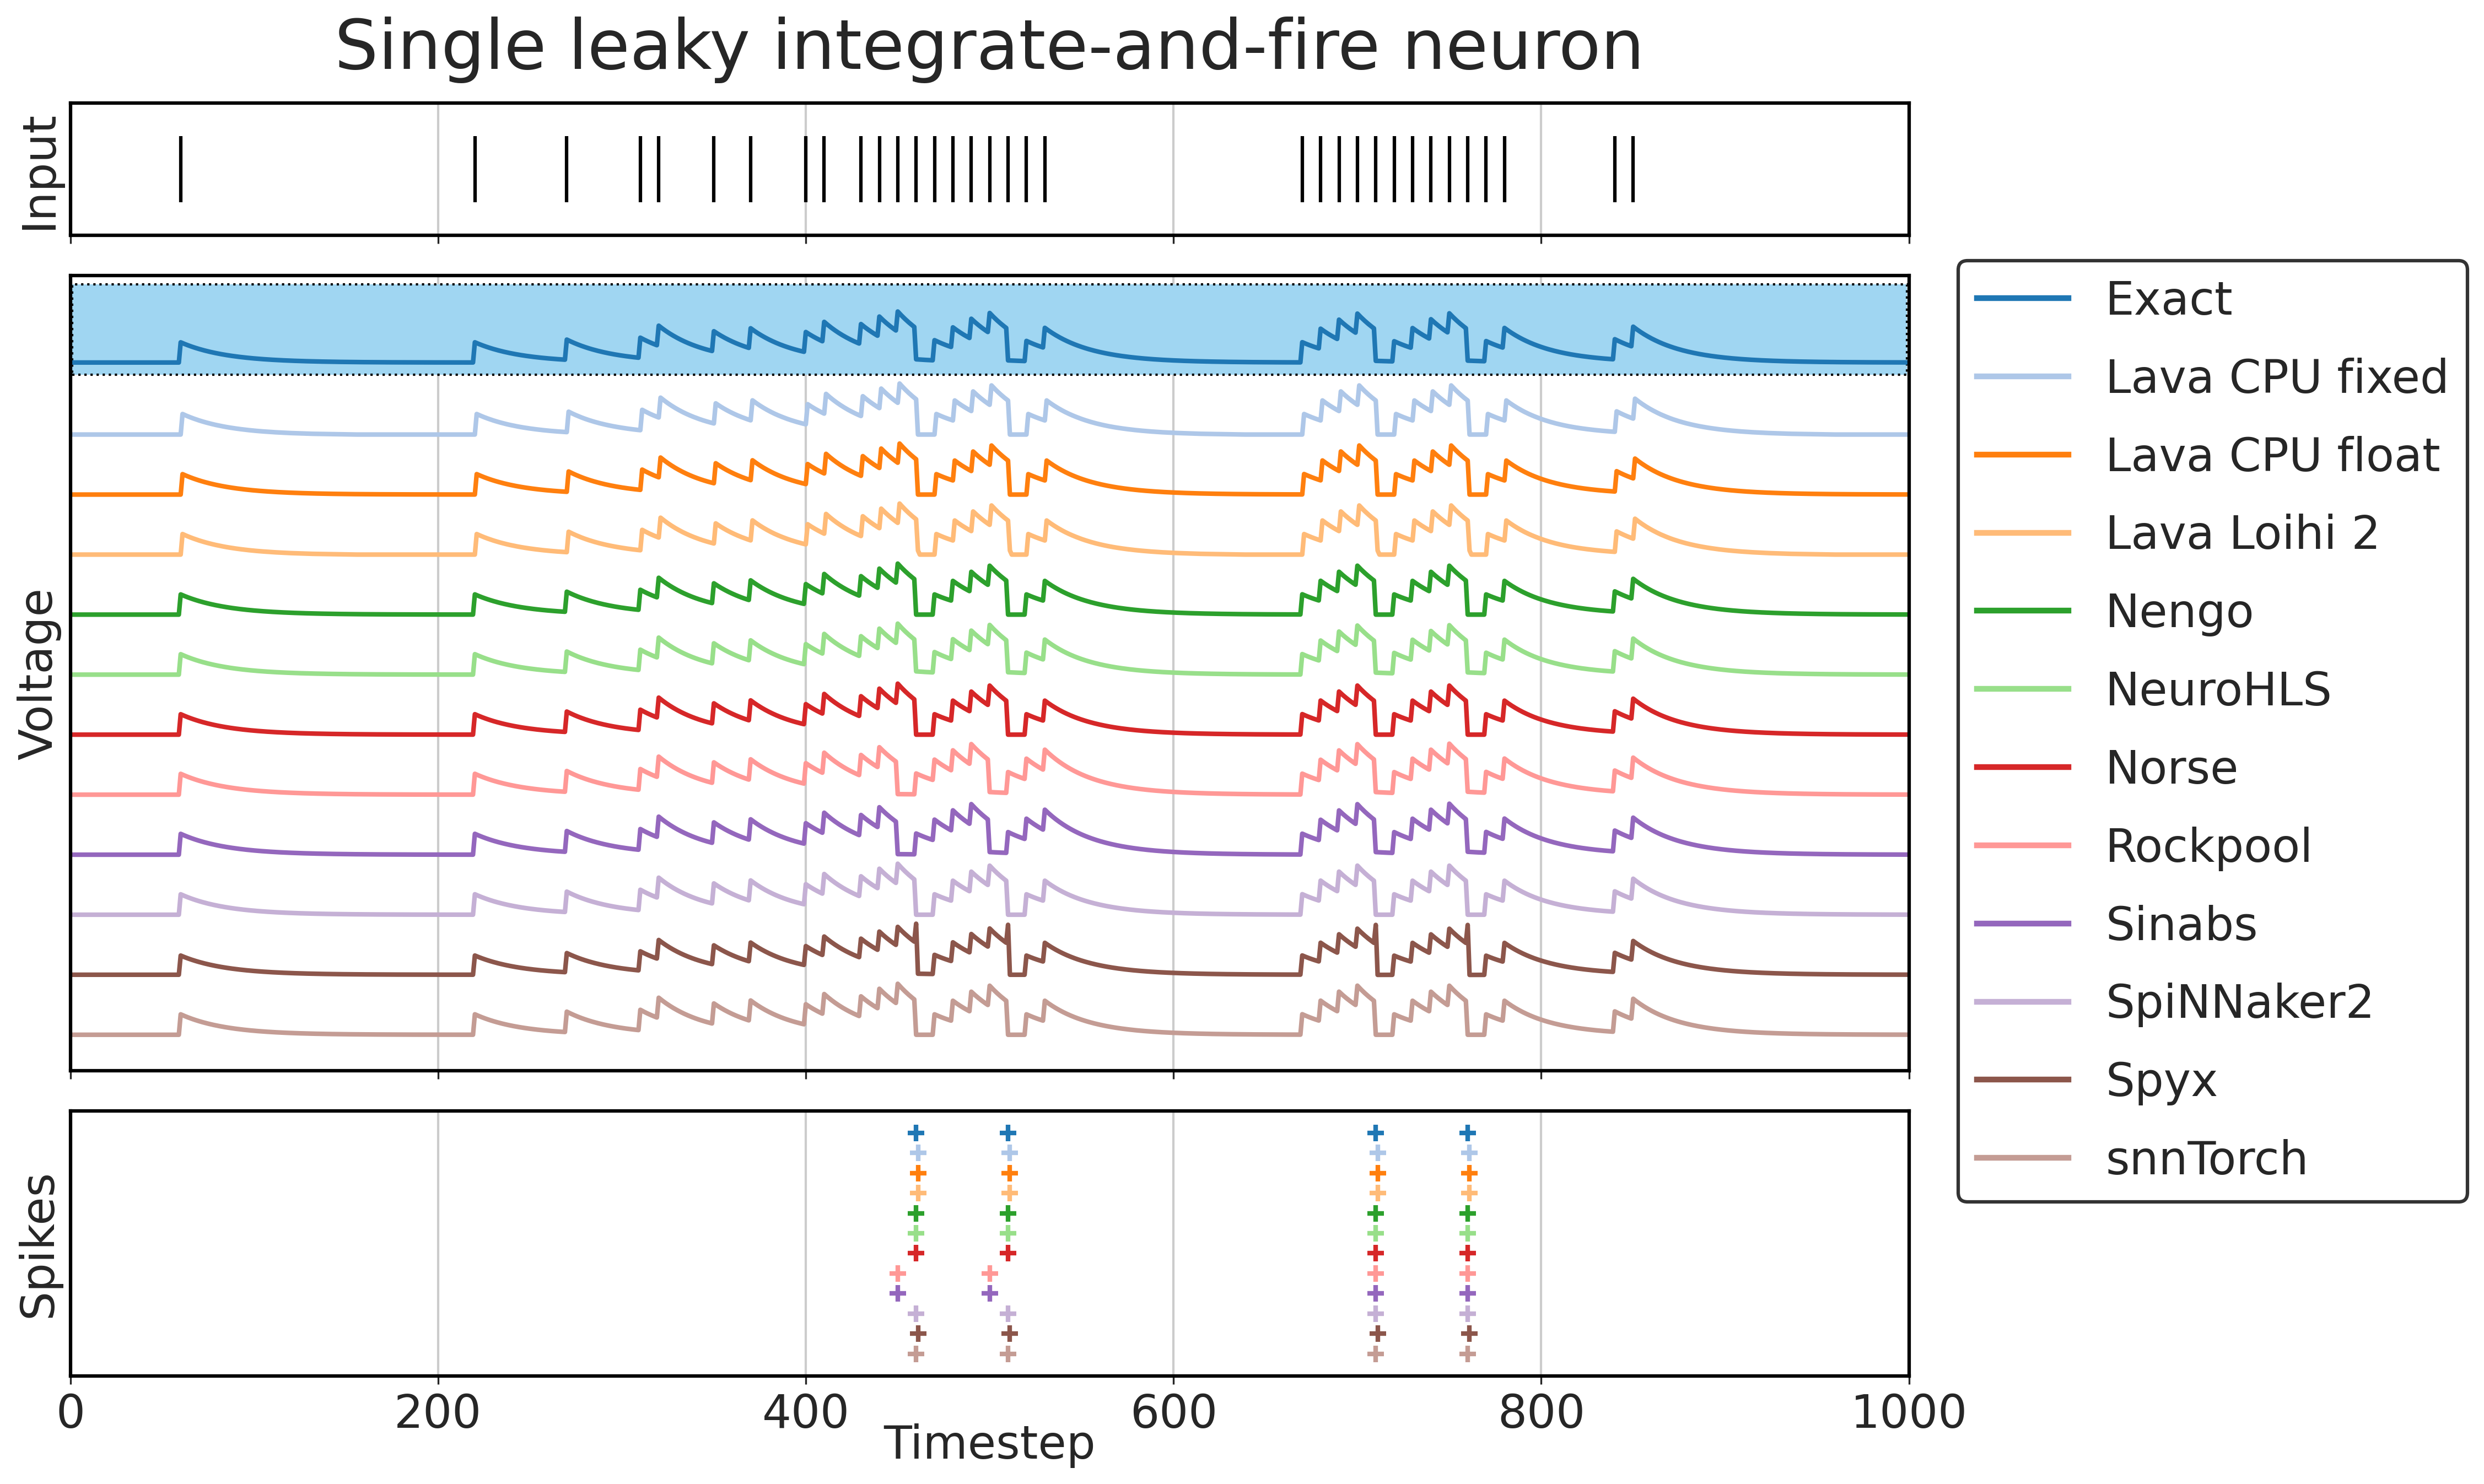

In [4]:
import matplotlib as mpl

# Estilo e layout do notebook publicado (nir_paper/01_lif/lif_comparison.ipynb):
# whitegrid, fonte sans 20 pt, bordas pretas de 1.5, tela 16x6 a 300 dpi e as
# tres faixas na proporcao 1:6:2.
vc.apply_paper_style()
mpl.rcParams.update({
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'legend.edgecolor': 'black',
})

traces = dict(references)
traces['NeuroHLS'] = trace


def normalised(frame):
    voltage = frame['voltage'].to_numpy(dtype=float, copy=True)
    return voltage / max(float(np.max(np.abs(voltage))), 1e-12)


voltages = sorted(
    ((name, normalised(frame)) for name, frame in traces.items()),
    key=lambda item: item[0],
)
spikes = sorted(
    ((name, np.flatnonzero(frame['spike'].to_numpy() > 0)) for name, frame in traces.items()),
    key=lambda item: item[0],
)
# O prop_cycle padrao tem 10 cores para as 12 implementacoes desta comparacao,
# entao duas ficariam com a mesma cor; tab20 da uma cor a cada uma.
colors = [mpl.colormaps['tab20'](index / 19) for index in range(len(voltages))]
steps = len(trace)

figure, (ax_input, ax_voltage, ax_spikes) = plt.subplots(
    3, 1, gridspec_kw={'height_ratios': [1, 6, 2], 'hspace': 0.1},
    sharex=True, figsize=(16, 10), dpi=300,
)

ax_input.set_title('Single leaky integrate-and-fire neuron', pad=15, fontsize=30)
ax_input.set_ylabel('Input')
ax_input.set_yticks([])
ax_input.eventplot(np.flatnonzero(trace['input'].to_numpy() > 0), colors='k')
ax_input.set_ylim(0, 2)
ax_input.set_xlim(0, steps)

# Tracos empilhados em vez de sobrepostos: com 12 implementacoes quase
# coincidentes, a sobreposicao esconde justamente as diferencas que o
# experimento mede.
for index, (name, voltage) in enumerate(voltages):
    if index == 0:
        # Faixa de destaque na referencia exata, como no grafico publicado.
        ax_voltage.add_artist(plt.Rectangle(
            (1, -0.2), steps - 2, 1.5,
            facecolor='#a0d6f2', edgecolor='black', linestyle='dotted',
        ))
        offset = 0
    else:
        offset = -index - 0.2
    ax_voltage.plot(voltage * 0.85 + offset, label=name, linewidth=2, color=colors[index])
ax_voltage.set_ylabel('Voltage')
ax_voltage.set_yticks([])
ax_voltage.grid(axis='y', alpha=0.5)

ax_spikes.set_ylabel('Spikes')
for index, (name, spike) in enumerate(spikes[::-1]):
    yval = 1 + index / (len(spikes) - 1)
    ax_spikes.scatter(
        spike, np.ones_like(spike) * yval, s=50, marker='+',
        color=colors[len(spikes) - index - 1], linewidths=2,
    )
ax_spikes.set_ylim(0.9, 2.1)
ax_spikes.set_yticks([])
ax_spikes.grid(axis='y', alpha=0.5)
ax_spikes.set_xlabel('Timestep', labelpad=-6)

# A ancora do notebook publicado foi ajustada para as 10 implementacoes dele;
# com 12 a legenda invade o eixo, entao o espaco e' reservado explicitamente e
# ela e' ancorada na faixa livre. tight_layout nao lida com legenda de figura.
figure.subplots_adjust(right=0.82)
legend = figure.legend(
    loc='center left', bbox_to_anchor=(0.83, 0.5), fontsize=20, labelspacing=0.73,
)
legend.get_frame().set_linewidth(1.5)
# legendHandles foi removido no matplotlib 3.10; legend_handles e o nome atual.
for handle in legend.legend_handles:
    handle.set_linewidth(2.5)

vc.save_paper_figure(figure, vc.RESULTS_ROOT / 'lif_comparison.png')
print(vc.RESULTS_ROOT / 'lif_comparison.png')
